In [12]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

In [3]:
df = pd.read_csv('data//classification.csv')
df.head()


,age,interest,success
0,23.657801,18.859917,0.0
1,22.573729,17.969223,0.0
2,32.553424,29.463651,0.0
3,6.718035,25.704665,1.0
4,14.401919,16.770856,0.0


In [8]:
X = df[['age', 'interest']]
y = df['success']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2)

Confusion matrix for k=1:
[[ 90  12]
 [ 23 113]]
AUC for k=1: 0.857

Confusion matrix for k=2:
[[ 98   4]
 [ 30 106]]
AUC for k=2: 0.906

Confusion matrix for k=3:
[[ 88  14]
 [ 17 119]]
AUC for k=3: 0.924

Confusion matrix for k=4:
[[ 93   9]
 [ 20 116]]
AUC for k=4: 0.944

Confusion matrix for k=5:
[[ 89  13]
 [ 20 116]]
AUC for k=5: 0.949

Confusion matrix for k=6:
[[ 94   8]
 [ 20 116]]
AUC for k=6: 0.947

Confusion matrix for k=7:
[[ 93   9]
 [ 20 116]]
AUC for k=7: 0.948



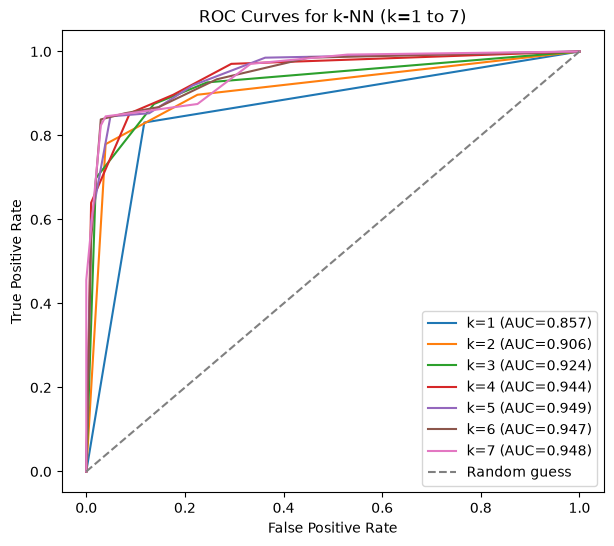

In [13]:
plt.figure(figsize=(7, 6))

for i in range(7):
    k = i + 1
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of positive class

    conf_matrix = confusion_matrix(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"k={k} (AUC={auc:.3f})")

    print(f"Confusion matrix for k={k}:\n{conf_matrix}")
    print(f"AUC for k={k}: {auc:.3f}\n")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for k-NN (k=1 to 7)")
plt.legend()
plt.show()

In [15]:
model_true = KNeighborsClassifier(n_neighbors=5)
model_true.fit(X_train, y_train)
y_pred_5 = model_true.predict(X_test)

In [16]:
accuracy_score(y_test, y_pred_5), precision_score(y_test, y_pred_5),recall_score(y_test, y_pred_5), f1_score(y_test, y_pred_5)


(0.8613445378151261,
 0.8992248062015504,
 0.8529411764705882,
 0.8754716981132076)